In [1]:
"Init"
from helper_funcs import *
import helper_funcs
import importlib
importlib.reload(helper_funcs)

from collections import defaultdict
import numpy as np
import pandas as pd

dirs = get_dirs(root="C:\\Users\\setht\\Dropbox\\Citadel\\GitHub\\otocoherence")
dpi = 500

# Get data
def get_data(T_xi_types):
    data = defaultdict(lambda: defaultdict(dict))

    for T_xi_type in T_xi_types:
        # Read df
        df = pd.read_excel(os.path.join(
            dirs["results"], rf"soae_T_xi [{T_xi_type}].xlsx"
        ))

        dfs = {}
        dfs["P"] = df[df["mode"]=="P"]
        dfs["phi"] = df[df["mode"]=="phi"]
        has_P = not (len(dfs["P"]) == 0)

        # Gather everything into lists
        if "cgram" in T_xi_type:
            prop_list = ["T_xi", "species", "wf_idx", "f0", "PSD"]
            N_xi_multiplier = "f0"
        else:
            prop_list = ["T_xi", "species", "wf_idx", "f0_max", "f0_fit"]
            N_xi_multiplier = "f0_max"

        for mode in ["phi", "P"]:
            if not has_P and mode == "P":
                continue
            for prop in prop_list:
                data[T_xi_type][mode][prop] = np.array(dfs[mode][prop])
  
            # Calculate derived data
            data[T_xi_type][mode]["N_xi"] = data[T_xi_type][mode]["T_xi"] * data[T_xi_type][mode][N_xi_multiplier]
            data[T_xi_type][mode]["inv_T_xi"] = 1/(data[T_xi_type][mode]["T_xi"])
        if has_P:
            data[T_xi_type]["T_xi_diffs"] = data[T_xi_type]["P"]["T_xi"] - data[T_xi_type]["phi"]["T_xi"]
            data[T_xi_type]["N_xi_diffs"] = data[T_xi_type]["P"]["N_xi"] - data[T_xi_type]["phi"]["N_xi"]

    return data

# Define universal variables

# Get peak centric variables from parameter dictionary
ppc = get_params_peakc()
pcg = get_params_cgram()
php = get_params_human_picking()


filt_id_peakc = ppc['filt_id']
meth_id_cgram = pcg['meth_id']


# Plotting parameters
markA='.'  # C_tau
markB='+'  # C_omega
markC='s'  # C_xi 
fontsize_ac = 14
dpi=500
fontsize_cgram = 40
labelpad = 20
fontsize_ticks = 20

lcc_kwargs = {
    "wf_len_s": pcg['wf_len_s'],
    "filter_meth": pcg['hpf_meth'],
    "mode":pcg['mode'],
    "xi_min_s": pcg['xi_min_s'],
    "win_meth": pcg['win_meth_cgram'],
    "nfft": pcg['nfft'],
    "pkl_folder": dirs["pickles"],
}

# Load noise floor
nf_fp = os.path.join(dirs["data"], 'testSOAEsupp1.txt')   # file name
nf_data = np.loadtxt(nf_fp)
f_nf = nf_data[:,0]
mags_nf = nf_data[:,1]

# Load colorblind accessible palette
cp = get_cp()

Note we're using a 50 dB rip on BPF, crank that up to 100!
Note we're using a 50 dB rip on BPF, crank that up to 100!
Note we're using a 50 dB rip on BPF, crank that up to 100!


In [ ]:
"Fig1"
wf_fn = 'ACsb24rearSOAEwfA1.mat'
wf, wf_fn, fs = get_wf(wf_fn)
wf=filter_wf_cgram(wf, fs, pcg['hpf_meth'])

# Params
tau = 1024
tau_hr = 3528
xi = 128
hop = int(round(fs*pcg["hop_cgram_s"])) # 10 ms
freq_bin_hop = 1 # For C_omega^phi
win = 'boxcar'
win_meth = {'method':'static', 'win_type':win}
win_meth_xi = win_meth

# # Calculate magnitude spectrum (avg_exp=1) and high res version
# f, mags = get_welch(wf, fs, tau, avg_exp=1, hop=hop, win=win) 
# f_hr, mags_hr = get_welch(wf, fs, tau_hr, avg_exp=1, hop=hop, win=win)
# # Convert to dB
# mags, mags_hr = 20*np.log10(mags), 20*np.log10(mags_hr)

# Calculate magnitude spectrum (avg_exp=1) and high res version
f, mags = get_welch(wf, fs, tau, avg_exp=2, hop=hop, win=win) 
f_hr, mags_hr = get_welch(wf, fs, tau_hr, avg_exp=2, hop=hop, win=win)
# Convert to dB
mags, mags_hr = 10*np.log10(mags), 10*np.log10(mags_hr)

# Calculate avg'd phases and autocoherences
C_xi_phi_dict = get_autocoherence(wf, fs, xi=xi, tau=tau, win_meth=win_meth_xi, mode='phi', ref_type='time', return_pd=True, return_dict=True)
C_tau_phi_dict = get_autocoherence(wf, fs, xi=tau, tau=tau, win_meth=win_meth, mode='phi', ref_type='time', return_pd=True, return_dict=True)
C_omega_phi_dict = get_autocoherence(wf, fs, xi=xi, tau=tau, win_meth=win_meth, mode='phi', ref_type='freq', freq_bin_hop=1, return_pd=True, return_dict=True)
# Extract autocoherences
C_xi_phi = C_xi_phi_dict['autocoherence']
C_tau_phi = C_tau_phi_dict['autocoherence']
C_omega_phi = C_omega_phi_dict['autocoherence']
# and <|Delta phi|>
avg_abs_pd_xi = C_xi_phi_dict['avg_abs_pd']
avg_abs_pd_tau = C_tau_phi_dict['avg_abs_pd']
avg_abs_pd_omega = C_omega_phi_dict['avg_abs_pd']
# Omega frequency array is shifted
f_omega = C_omega_phi_dict['f']

# Plotting parameters
markA='.'  # C_tau
markB='+'  # C_omega
markC='s'  # C_xi 
# freq. limits for plotting [kHz]
fmin, fmax = 0.4, 5
fmin_idx, fmax_idx = np.argmin(np.abs(f-fmin*3000)), np.argmin(np.abs(f-fmax*3000))
title = rf"anole_{wf_fn[:-4]}: $\tau={1000*tau/fs:.2f}$ ms & $\xi={1000*xi/fs:.2f}$ ms"
yoff_hr = 5.5 # Shift highres mags' "floating" dB scale up to line things up
yoff_nf = -60.5 # Shift noisefloor mags' "floating" dB scale up to line things up
micNF = 0.5
ylim_pad=[6,3] # Ylimit padding below/above mags on ylimits
ylims_left = [0, 0.6]

# Initialize plot
plt.close('all')
fig, ax = plt.subplots(3, 1, figsize=(6.4, 4.8 * 1.5))

"Magnitude Subplot"
ax[0].plot(f_hr/1000,mags_hr+yoff_hr,linestyle='-', lw=3,
                color=cp['purple'],alpha=0.3,label='Avg. Magnitude (High Res.)')
# === mags. on top
ax[0].plot(f/1000,mags,linestyle='-', marker=markA, 
                ms=7,color='k',label='Avg. Magnitude')

# -- include mic noise floor
ax[0].plot(f_nf/1000,mags_nf+yoff_nf,linestyle='--',color='g',lw=micNF,
            alpha=0.5,label='Est. Noise Floor')
#
#ax5[0].set_xlabel('Frequency [kHz]')  
fracLS= 0.05  # scaling fraction to help w/ vert. lims {0.05}
ax[0].set_ylabel('Magnitude [dB]',fontsize=12)
ax[0].set_title(title,fontsize=8,loc='right',color=[0.5,0.5,0.5]) 
ax[0].set_xlim(fmin, fmax)
# ax[0].legend(loc="upper right")
ax[0].grid()
ax[0].set_ylim([np.min(mags[fmin_idx:(fmax_idx+1)])-ylim_pad[0],
                np.max(mags[fmin_idx:(fmax_idx+1)])+ylim_pad[1]])

"<|Delta phi|> Subplot"
ax[1].plot(f/1000,avg_abs_pd_tau,linestyle='-',marker=markA, 
                color='k',label=r'$\langle|\Delta \phi_\tau|\rangle$')
ax[1].plot(f_omega/1000,avg_abs_pd_omega,linestyle='--',marker=markB, 
                color='r',label=r'$\langle|\Delta \phi_\omega|\rangle$')
ax[1].plot(f/1000,avg_abs_pd_xi,linestyle='-.',marker=markC, 
                color='b',label=r'$\langle|\Delta \phi_\xi|\rangle$',markersize=2)
ax[1].set_ylabel(r"$\langle|\Delta \phi|\rangle$ [rads]",fontsize=12) 
ax[1].legend(loc="lower right")
ax[1].grid()
ax[1].set_xlim(fmin, fmax)

"Autocoherence Subplot"
# ===  coherence on bottom
Lb1= ax[2].plot(f/1000,C_tau_phi,linestyle='-', 
                marker=markA,color='k',label=r'$C_\tau$')
Lb2= ax[2].plot(f_omega/1000, C_omega_phi,'r',lw=1,linestyle='--',
                marker=markB,label=r'$C_\omega$',markersize=4)
# --- use right y-axis for C_xi
ax5b = ax[2].twinx()
Lb3= ax5b.plot(f/1000,C_xi_phi,'b',lw=1,linestyle='-.',
                marker=markC,label=r'$C_\xi$',markersize=2)
# same axis limits on both sides
ax5b.set_ylim([-0.05,1.05])
ax[2].set_xlabel('Frequency [kHz]',fontsize=12)  
ax[2].set_ylabel(r'Autocoherence ($C_\tau$ & $C_\omega$)',fontsize=12) 
ax5b.set_ylabel(r'Autocoherence ($C_{\xi}$)',fontsize=12,color='b') 
ax[2].grid()
ax[2].set_xlim(fmin, fmax)
ax[2].set_ylim(ylims_left)
LbT = Lb1+Lb2+Lb3  # deal w/ legend given multiple ordinates
labelF5 = [l.get_label() for l in LbT]
ax[2].legend(LbT,labelF5,loc="center right")
plt.tight_layout()
plt.savefig(os.path.join(dirs["figs"], 'Fig1.jpg'), dpi=dpi, bbox_inches='tight')



Cropping waveform!
Tokay
Filtering wf with cf=300Hz, df=50Hz, rip=100dB
Filtering took 4.237s
1161
580
Processing 'C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\pickles\Tokay 0, mode=phi, rho=1.0, hann, hop=500, tau=7500, HPF=(300Hz cf, 50Hz df, 100dB rip), xi_max=100ms, nfft=None, N_pd=max, DM=True, wf_len=60s, wf=tokay_GG1rearSOAEwf (Colossogram).pkl'


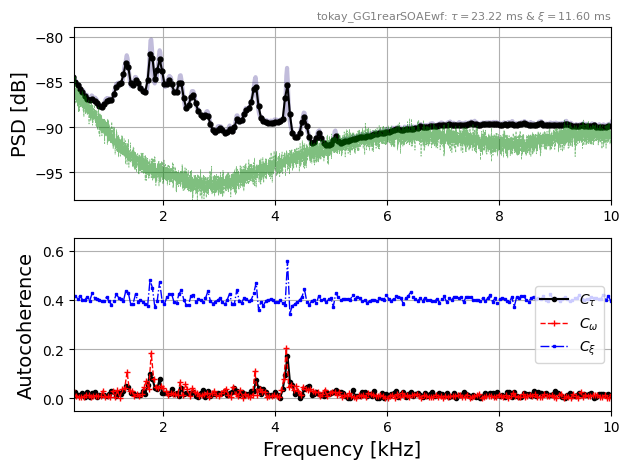

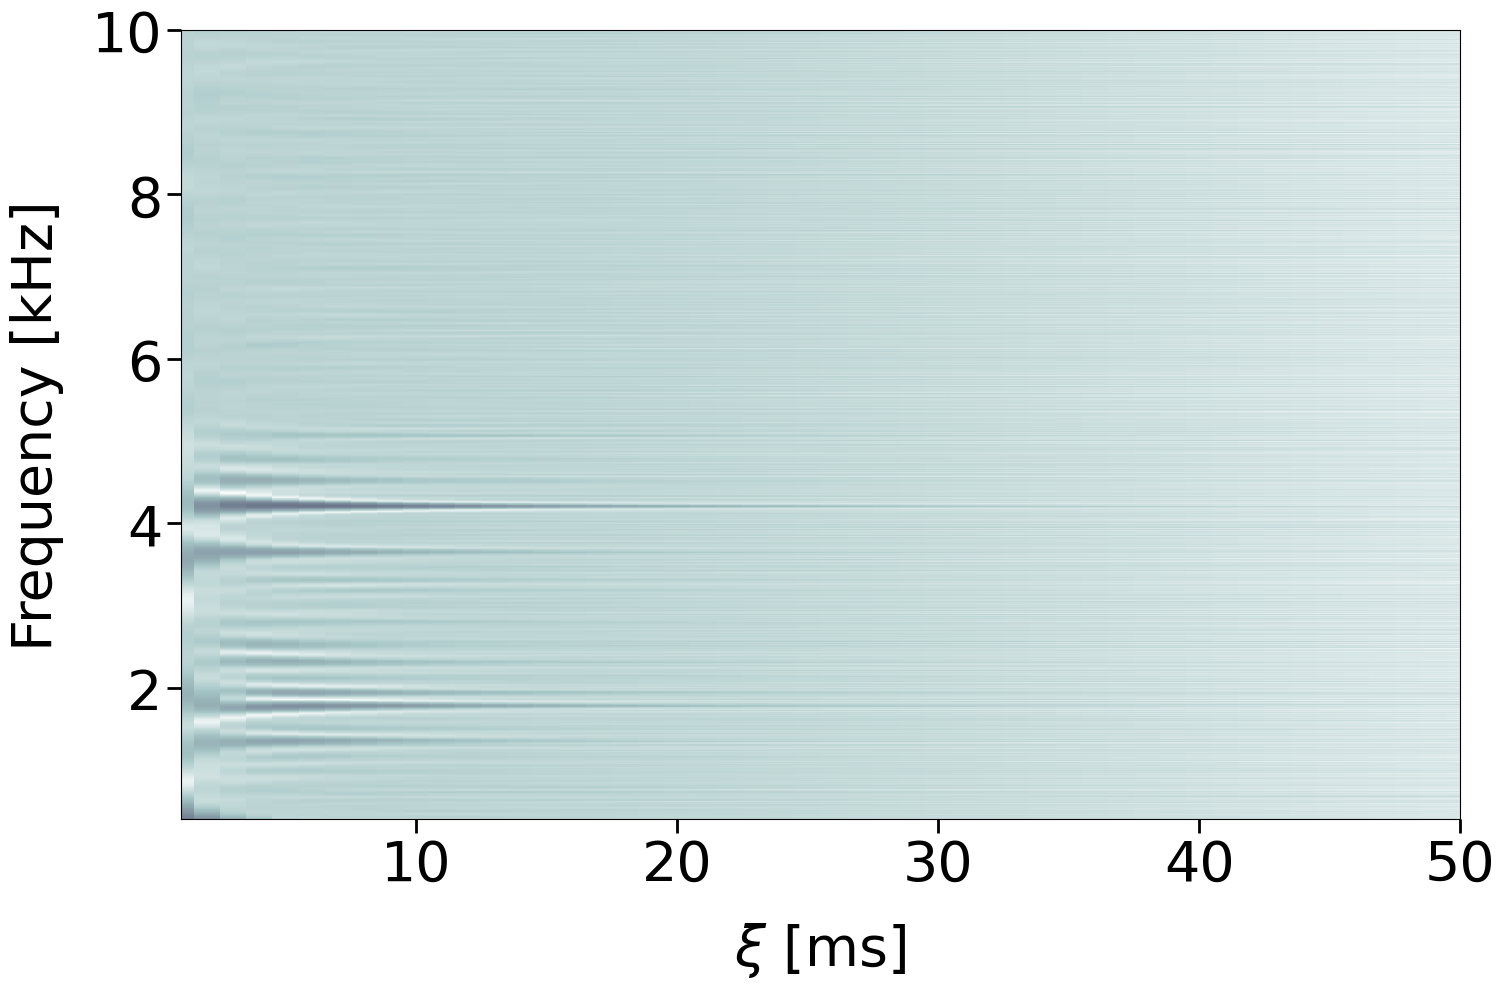

In [ ]:
"Fig2"
# Species dependent params
subjects = [('Human', 1), ('Owl', 2), ('Anole', 0), ('Tokay', 0)]
subjects = [('Tokay', 0)]
flims = {'Human':(0.4, 10), 'Owl':(2, 11), 'Anole':(0.4, 5), 'Tokay':(0.4, 5)}
yoff_hrs = {'Human':2.5, 'Owl':5.5, 'Anole':5.5, 'Tokay':5.5}
yoff_nfs = {'Human':-66, 'Owl':-61.5, 'Anole':-61.5, 'Tokay':-68.5}
# taus_C = {'Human':2048, 'Owl':1024, 'Anole':1024, 'Tokay':1161}
taus_C_mags_s = {'Human':0.04644, 'Owl':0.02322, 'Anole':0.02322, 'Tokay':0.02322}
# xis_C = {'Human':1024, 'Owl':512, 'Anole':512, 'Tokay':580}
xis_C_mags_s = {'Human':0.02322, 'Owl':0.01161, 'Anole':0.01161, 'Tokay':0.01161}
Cmins = {'Human':-0.05, 'Owl':-0.05, 'Anole':-0.05, 'Tokay':-0.05}
Cmin_xis = {'Human':-0.05, 'Owl':-0.05, 'Anole':-0.05, 'Tokay':-0.05}
Cmaxs = {'Human':1.05, 'Owl':0.9, 'Anole':0.65, 'Tokay':0.65}
Cmax_xis = {'Human':1.05, 'Owl':1.05, 'Anole':0.65, 'Tokay':0.65}

# Params for mags
tau_mags_hr_s = 0.08
hop_C_mags_s = 0.01 # Just doing 10ms for consistency
win_type_mags = ppc["win_type"] # Use the same as peak centric PSD calculations

# Colossogram
xi_max_ss = {'Human':1.0, 'Owl':0.1, 'Anole':0.1, 'Tokay':0.1}
cgram_xmaxs = {'Human':1000, 'Owl':50, 'Anole':50, 'Tokay':50}

# Load noise floor
nf_fp = os.path.join(dirs["data"], 'testSOAEsupp1.txt')   # file name
nf_data = np.loadtxt(nf_fp)
f_nf = nf_data[:,0]
mags_nf = nf_data[:,1]


for (species, wf_idx) in subjects:
    "First two rows"
    # Get waveform
    wf, wf_fn, fs = get_wf(species=species, wf_idx=wf_idx)
    print(species)
    # Preprocess
    wf=filter_wf_cgram(wf, fs, pcg['hpf_meth'])

    # Define win meth
    win_meth = {'method':'static', 'win_type':'boxcar'}

    # Get species-specific method parameters
    tau_C_mags = int(round(taus_C_mags_s[species] * fs))
    xi_C_mags = int(round(xis_C_mags_s[species] * fs))
    print(tau_C_mags)
    print(xi_C_mags)

    # Get species-specific plotting param
    flim = flims[species]
    yoff_hr = yoff_hrs[species] # Shift highres mags' "floating" dB scale up to line things up
    yoff_nf =  yoff_nfs[species] # Shift noisefloor mags' "floating" dB scale up to line things up
    Cmax = Cmaxs [species]
    Cmax_xi = Cmax_xis [species]
    Cmin = Cmins [species]
    Cmin_xi = Cmin_xis [species]

    # Get universal params in terms of this fs
    tau_cgram = int(round(pcg['tau_s'] * fs))
    hop_cgram = int(round(pcg['hop_cgram_s'] * fs))
    # Get mags params in terms of this fs
    tau_mags_hr = int(round(tau_mags_hr_s * fs))
    hop_mags = int(round(hop_C_mags_s * fs))

    


    # Calculate PSD and high res version
    f_lr, mags_lr = pc.get_welch(wf, fs, tau_C_mags, hop=hop_mags, avg_exp=1, win=win_type_mags) 
    f_hr, mags_hr = pc.get_welch(wf, fs, tau_mags_hr, hop=hop_mags, avg_exp=1, win=win_type_mags)

    # Convert to dB
    mags_lr, mags_hr = 20*np.log10(mags_lr), 20*np.log10(mags_hr)
    # Calculate autocoherences
    C_xi_phi = pc.get_autocoherence(wf, fs, xi=xi_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi')[1]
    C_tau_phi = pc.get_autocoherence(wf, fs, xi=tau_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi')[1]
    f_omega, C_omega_phi = pc.get_autocoherence(wf, fs, xi=xi_C_mags, tau=tau_C_mags, win_meth=win_meth, mode='phi', ref_type='freq', freq_bin_hop=1)
    
    # freq. limits for plotting [kHz]
    fmin, fmax = flim[0], flim[1]
    fmin_idx, fmax_idx = np.argmin(np.abs(f_lr-fmin*1000)), np.argmin(np.abs(f_lr-fmax*1000))
    if species not in ['Owl', 'Tokay']:
        title = rf"{species.lower()}_{wf_fn[:-4]}: $\tau={1000*tau_C_mags/fs:.2f}$ ms & $\xi={1000*xi_C_mags/fs:.2f}$ ms"
    else:
        title = rf"{wf_fn[:-4]}: $\tau={1000*tau_C_mags/fs:.2f}$ ms & $\xi={1000*xi_C_mags/fs:.2f}$ ms"

    ylim_pad=[6,3] # Ylimit padding below/above mags on ylimits

    # Initialize plot
    plt.close('all')
    fig, ax = plt.subplots(2, 1, figsize=(6.4, 4.8))

    "Magnitude Subplot"
    ax[0].plot(f_hr/1000,mags_hr+yoff_hr,linestyle='-', lw=3,
                    color=cp['purple'],alpha=0.3,label='PSD (High Res.)')
    # === mags. on top
    ax[0].plot(f_lr/1000,mags_lr,linestyle='-', marker=markA, 
                    ms=7,color='k',label='PSD')

    # -- include mic noise floor
    ax[0].plot(f_nf/1000,mags_nf+yoff_nf,linestyle='--',color='g',lw=0.5,
                alpha=0.5,label='Est. Noise Floor')
    #
    #ax5[0].set_xlabel('Frequency [kHz]')  
    fracLS= 0.05  # scaling fraction to help w/ vert. lims {0.05}
    ax[0].set_ylabel('PSD [dB]',fontsize=fontsize_ac)
    ax[0].set_title(title,fontsize=8,loc='right',color=[0.5,0.5,0.5]) 
    ax[0].set_xlim(fmin, fmax)
    # ax[0].legend(loc="upper right")
    ax[0].grid()
    ax[0].set_ylim([np.min(mags_lr[fmin_idx:(fmax_idx+1)])-ylim_pad[0],
                    np.max(mags_lr[fmin_idx:(fmax_idx+1)])+ylim_pad[1]])


    "Autocoherence Subplot"
    # ===  coherence on bottom
    Lb1= ax[1].plot(f_lr/1000,C_tau_phi,linestyle='-', 
                    marker=markA,color='k',label=r'$C_\tau$')
    Lb2= ax[1].plot(f_omega/1000, C_omega_phi,'r',lw=1,linestyle='--',
                    marker=markB,label=r'$C_\omega$',markersize=4)
    # --- use right y-axis for C_xi
    # ax5b = ax[1].twinx()
    # Lb3= ax5b.plot(f/1000,C_xi_phi,'b',lw=1,linestyle='-.', marker=markC,label=r'$C_\xi$',markersize=2)
    Lb3 = ax[1].plot(f_lr/1000,C_xi_phi,'b',lw=1,linestyle='-.',
                    marker=markC,label=r'$C_\xi$',markersize=2)

    # same axis limits on both sides
    # ax5b.set_ylim([Cmin_xi,Cmax_xi])
    ax[1].set_xlabel('Frequency [kHz]',fontsize=fontsize_ac)  
    # ax[1].set_ylabel(r'Autocoherence ($C_\tau$ & $C_\omega$)',fontsize=fontsize_ac) 
    ax[1].set_ylabel(r'Autocoherence',fontsize=fontsize_ac) 
    # ax5b.set_ylabel(r'Autocoherence ($C_{\xi}$)',fontsize=12,color='b') 
    ax[1].grid()
    ax[1].set_xlim(fmin, fmax)
    ax[1].set_ylim([Cmin,Cmax])
    LbT = Lb1+Lb2+Lb3  # deal w/ legend given multiple ordinates
    labelF5 = [l.get_label() for l in LbT]
    ax[1].legend(LbT,labelF5,loc="center right")
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figs"], f'Fig2R1 ({species}).jpg'), dpi=dpi, bbox_inches='tight')

    "Colossogram Plot"
    fp_pp = os.path.join(dirs["results"], "picked_peaks.json")
    picked_peaks = get_picked_peaks(fp_pp, wf_fn)

    # Load Colossogram
    cgram_dict = load_calc_colossogram(
        **(
            lcc_kwargs
            | {
                "xi_max_s": xi_max_ss[species],
                "species": species,
                "fs": fs,
                "tau": tau_cgram,
                "hop": hop_cgram,
                "wf": wf,
                "wf_idx": wf_idx,
                "wf_fn": wf_fn,
            }
        )
    )


    # Load everything that wasn't explicitly "saved" in the filename
    colossogram = cgram_dict["colossogram"]
    fn_id = cgram_dict["fn_id"]
    win_meth_str = cgram_dict["win_meth_str"]
    method_id = cgram_dict["method_id"]
    filter_str = cgram_dict["filter_str"]
    f_cgram = cgram_dict["f"]
    xis_s = cgram_dict["xis_s"]
    # good_peak_idxs = np.argmin(np.abs(f[:, None] - good_peak_freqs[None, :]), axis=0)
    # method_id = rf"[$\tau$={(tau/fs)*1000:.2f}ms]   [Mode=$\phi$]   [{win_meth_str}]   [Hop={hop_s*1000:.1f}ms]   [{N_pd_str}]   [nfft={nfft}]"
    # suptitle = (
    #     rf"[{species} {wf_idx}]   [{wf_fn}]   [HPBW={bw}Hz]   {method_id}   [{filter_str}]"
    # )
    suptitle=None

    # MAKE PLOT
    plt.figure(figsize=(18, 10))
    cbar = pc.plot_colossogram(cgram_dict, cmap="bone_r", return_cbar=True)
    # Set Chris' requested fontsizes
    ax = plt.gca()
    ax.set_xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fontsize_cgram)
    ax.set_ylabel("Frequency [kHz]", labelpad=labelpad, fontsize=fontsize_cgram)
    ax.tick_params(axis='both', which='major', length=10, width=2)
    ax.tick_params("both", labelsize=fontsize_cgram)
    cbar.ax.yaxis.label.set_fontsize(fontsize_cgram)
    cbar.ax.tick_params(labelsize=fontsize_cgram)
    if species != 'Human':
        cbar.ax.remove()

    xmin = xis_s[0] * 1000
    xmax = cgram_xmaxs[species]
    plt.ylim(fmin, fmax)
    plt.xlim(xmin, xmax)

    for f0_max in picked_peaks:
        f0_idx = np.argmin(np.abs(f_cgram - f0_max))
        plt.scatter(
            xmin / 2,
            f_cgram[f0_idx] / 1000,
            c="purple",
            marker=">",
            label="Peak at " + f"{f_cgram[f0_idx]:0f}Hz",
            alpha=0.5,
            s=100
        )

    # plt.title(f"Colossogram", fontsize=18)
    # plt.suptitle(suptitle, fontsize=10)
    plt.tight_layout()
    plt.savefig(
        os.path.join(dirs["figs"], f"Fig2R2 ({species}).jpg"),
        dpi=dpi,
    )


    
    

In [ ]:
"Fig2.5 T_xi specs"
data_cgram = get_data([meth_id_cgram])[meth_id_cgram][pcg["mode"]]
df_cgram = pd.DataFrame(data_cgram)

fsz = 24
figsize = (10, 5)
alpha_sig = 1
alpha_insig = 0.25
s_sig = 5
s_insig = 1

flims = {'Anole':[1, 6], 'Human':[1, 10], 'Owl':[1, 12], 'Tokay':[1, 6]}
T_xi_thresh = 0.005

for species, wf_idx in (('Human', 1), ('Owl', 3), ('Anole', 0), ('Tokay', 0)):
    wf_fn = get_wf_fn(species=species, wf_idx=wf_idx)
    df_sidx = df_cgram[(data_cgram["species"] == species) & (data_cgram["wf_idx"] == wf_idx)]
    f_lr = df_sidx["f0"]
    T_xi = df_sidx["T_xi"]
    psd = df_sidx["PSD"]

    fmin, fmax = (np.array(flims[species]))*1000  
    fmin_idx = np.argmin(np.abs(f_lr-fmin))
    fmax_idx = np.argmin(np.abs(f_lr-fmax))
    T_xis_idxs = np.arange(len(T_xi))
    sig_mask = (T_xi >= T_xi_thresh) & (T_xis_idxs > fmin_idx) & (T_xis_idxs < fmax_idx)

    
    fmin_idx_plot, fmax_idx_plot = np.argmin(np.abs(f_lr-fmin)), np.argmin(np.abs(f_lr-fmax))
    f_plot = f_lr[fmin_idx_plot:fmax_idx_plot]
    sig_mask_plot = sig_mask[fmin_idx_plot:fmax_idx_plot]
    T_xis_plot = T_xi[fmin_idx_plot:fmax_idx_plot]

    # Plot PSD 
    psd_plot = psd[fmin_idx_plot:fmax_idx_plot]
    psd_db_plot = 10*np.log10(psd_plot)
    plt.close('all')
    plt.figure(figsize=figsize) 
    plt.ylabel(rf"PSD [dB]", color="orange", fontsize=fsz)
    plt.xlabel("Frequency [Hz]", fontsize=fsz)
    plt.plot(f_plot, psd_db_plot, color="orange")

    # Plot T_xi Spectrum
    plt.twinx()
    plt.scatter(f_plot[sig_mask_plot], T_xis_plot[sig_mask_plot], s=s_sig, alpha=alpha_sig, color=cp["purple"])
    plt.scatter(f_plot[~sig_mask_plot], T_xis_plot[~sig_mask_plot], s=s_insig, alpha=alpha_insig, color=cp["purple"])
    plt.ylabel(rf"$T_\xi$ [s]", color=cp["purple"], fontsize=fsz)
    plt.tight_layout()
    plt.title(wf_fn, loc="right", alpha=0.5)
    fn_T_xi_spec = f"T_xi Spectrum - {species} {wf_idx}.jpg"
    plt.savefig(os.path.join(dirs["figs"], fn_T_xi_spec), dpi=dpi)

In [ ]:
"Fig3A (BPF and T_xi_int process)"

colors = {"Anole":"#07586E", "Human":"#8C60B3"}
T_xi_len_ss = {"Anole":ppc['T_xi_len_s'], "Human":0.5}
xmaxs = {"Anole":50, "Human":1000}
fsz_fig3A = 40

for (species, wf_idx, f0_max_saved) in [("Anole", 1, 3152.0), ("Human", 2, 1634.0)]:
    # Get waveform and picked peaks
    wf, wf_fn, fs = get_wf(
        species=species,
        wf_idx=wf_idx,
    )
    fp_pp = os.path.join(dirs["results"], "picked_peaks.json")
    picked_peaks = get_picked_peaks(fp_pp, wf_fn)

    # Get params for this fs
    tau, hop = int(round(ppc["tau_s"] * fs)), int(round(ppc["hop_s"] * fs)) 
    # Get PSD For fitting to
    f, psd = pc.get_welch(wf, fs, tau, hop=hop, win=ppc["win_type"], nfft=ppc["nfft"])
    fab = fit_and_bpf(wf, fs, f, psd, f0_max_saved, ppc)
    
    # Get species-specific params
    color = colors[species]
    T_xi_len_s = T_xi_len_ss[species]
    xmax = xmaxs[species]

    # MAKE PLOT
    plt.close('all')
    fig = plt.figure(figsize=(18, 10))
    ax = fig.add_axes([0.2, 0.2, 0.8, 0.7])  # [left, bottom, width, height] in figure fraction
    if pcg["mode"] == "phi":
        acf_fab_str = 'acf_phi_full'
    elif pcg["mode"] == "P":
        acf_fab_str = 'acf_full'
    else:
        raise ValueError
        
    ax.plot(fab['lags_full_s'] * 1e3, fab[acf_fab_str], color=color)
    mask = fab['lags_full_s'] <= T_xi_len_s
    ax.fill_between(
        fab['lags_full_s'] * 1e3,
        fab[acf_fab_str],
        0,
        where=mask,
        alpha=0.3,
        color=color,
    )
    plt.xlim(0, xmax)

    ax.set_xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fsz_fig3A)
    ax.set_ylabel(r"$C_\xi$", labelpad=labelpad, fontsize=fsz_fig3A)
    plt.suptitle(f"{wf_fn} {f0_max_saved} Hz")
    # ax.legend(fontsize=fontsize_cgram-10, loc="upper right")
    # ax.get_legend().remove()

    ax.tick_params('both', labelsize=fsz_fig3A)

    # plt.title(f"Colossogram", fontsize=18)
    # plt.suptitle(suptitle, fontsize=10)
    # plt.tight_layout()
    plt.savefig(os.path.join(dirs['figs'], f'Fig3A ({species}).jpg'), dpi=dpi, bbox_inches='tight')

    "Make PSD filtering visualization plot"
    f_crop = fab['f_crop']
    crop_idxs = fab['crop_idxs']
    lorentz_fit = fab['lorentz_fit']

    # Conversions
    psd_db = 10*np.log10(psd)
    f_khz = f / 1000
    f_crop_khz = f_crop / 1000
    psd_crop_db = psd_db[crop_idxs[0]:crop_idxs[1]]
    lorentz_fit_db = 10*np.log10(lorentz_fit)
    
    # Crop to the fit plus some bins (only used for plotting)
    extra_bin_fact = 1
    bin_width = f[1]-f[0]
    bw_filt = fab['bw_filt']
    extra_bins = int(round((bw_filt)*extra_bin_fact/(bin_width)))
    
    # Do the crop
    crop_plus_slice = slice(crop_idxs[0] - extra_bins, crop_idxs[1] + extra_bins)
    f_khz_crop_plus = f_khz[crop_plus_slice]
    psd_crop_plus = psd[crop_plus_slice]

    # Compute psd on the filtered waveform
    psd_filt = pc.get_welch(fab['wf_filt'], fs, tau, hop=hop, win=ppc["win_type"], nfft=ppc["nfft"])[1]
    psd_filt_db = 10*np.log10(psd_filt)

    # Plot individual lorentzian fit
    fig = plt.figure(figsize=(18, 10))
    ax = fig.add_axes([0.2, 0.2, 0.8, 0.7])  # [left, bottom, width, height] in figure fraction
    lw_PSD = 5
    lw_fit = 15
    ax.plot(f_khz_crop_plus, psd_crop_plus, label='PSD', color='k', lw=lw_PSD, alpha=0.7)
    ax.plot(f_crop_khz, lorentz_fit, label="Lorentzian Fit", color='green', lw=lw_fit, alpha=0.3)
    ax.plot(f_khz, psd_filt, label="Filtered PSD", lw=lw_PSD, color=cp['purple'])
    ax.set_ylabel("PSD", fontsize=fsz_fig3A)
    ax.set_xlabel("Frequency [Hz]", fontsize=fsz_fig3A, labelpad=labelpad)
    ax.legend(fontsize=fsz_fig3A)
    ax.set_xlim(f_khz_crop_plus[[0, -1]])
    ax.tick_params('both', labelsize=fsz_fig3A)
    plt.savefig(os.path.join(dirs["figs"], f"Fig3A ({species} - PSD).jpg"), dpi=dpi, bbox_inches="tight")




In [ ]:
"Fig3B (Qerb and N_xi vs Freq)"
meth_id_peak_centric = f"int 25ms, {filt_id_peakc}"
meth_id_peak_centric_long = f"int 500ms, {filt_id_peakc}"

data = get_data((meth_id_peak_centric, meth_id_peak_centric_long))
fig_fp_id = f"int {meth_id_peak_centric[4:8]} ({meth_id_peak_centric_long[4:8]} Human)"

mode = pcg["mode"]

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["N_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Qerb and {tc} vs Freq [{fig_fp_id}].jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}
    
    # Plot Q_ERB
    plt.plot(
        freqANFtokay,
        QerbANFtokay,
        "+",
        color="green",
        alpha=0.4,
        ms=4,
        lw=1,
        markerfacecolor="green",
        label=r"Tokay $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    plt.plot(
        freqANFowl,
        QerbANFowl,
        "d",
        color="orange",
        alpha=0.3,
        ms=3,
        lw=1,
        markerfacecolor="orange",
        label=r"Owl $Q_{ERB}$" if tc == "N_xi" else r"Tokay $Q_{ERB}/f$",
    )

    # Plot Human
    human_mask = [sp == "Human" for sp in data[meth_id_peak_centric_long][mode]["species"]]
    plt.scatter(
            (data[meth_id_peak_centric_long][mode]["f0_max"] / 1000)[human_mask],
            data[meth_id_peak_centric_long][mode][tc][human_mask],
            marker=markers["Human"],
            color=colors["Human"],
            lw=mews["Human"],
            alpha=alpha_human_long,
            s=s_human_long,
            facecolors=mfcs["Human"],
            label=f"Human [{meth_id_peak_centric_long[4:9]}]",
        )
    
    # Plot deltas
    mask_deltas = [sp == "Human" and freq > delta_mask_fmin and freq < delta_mask_fmax for sp, freq in zip(data[meth_id_peak_centric][mode]["species"], data[meth_id_peak_centric][mode]["f0_max"])]
    plt.vlines(
        data[meth_id_peak_centric][mode]["f0_max"][mask_deltas] / 1000,
        ymin=np.minimum(data[meth_id_peak_centric][mode]["N_xi"][mask_deltas], data[meth_id_peak_centric_long][mode]["N_xi"][mask_deltas]),
        ymax=np.maximum(data[meth_id_peak_centric][mode]["N_xi"][mask_deltas], data[meth_id_peak_centric_long][mode]["N_xi"][mask_deltas]),
        lw=1,
        color=cp["blue"],
        zorder=0,
        alpha=alpha_human_line
    )


    # Plot X_xis
    for s in set(data[meth_id_peak_centric][mode]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric][mode]["species"]]

        plt.scatter(
            (data[meth_id_peak_centric][mode]["f0_max"] / 1000)[mask_species],
            data[meth_id_peak_centric][mode][tc][mask_species],
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            label=f"{s} [{meth_id_peak_centric[4:8]}]",
        )
    




    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(0.5, 5e3)
    elif tc=="T_xi":
        plt.ylim(1e-3, 1e2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"ANF $Q_{{ERB}}$ & SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

In [ ]:
"Fig3C (NDDHO)"

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


T_xi_len_s = ppc["T_xi_len_s"]
T_xi_len_s = 25
# qs = [50, 75, 100, 125, 150, 175, 200]
qs = [20, 40, 60, 80, 100]

# ======================================================
fp= os.path.join(dirs["results"], f'NDDHO N_xi Data [T_xi_len_s={T_xi_len_s}, Qs={qs}, {ppc["T_xi_id"]}, {ppc["filt_id"]}].xlsx')
# ======================================================

# use a function to do the averaging from the Excel file
def compAVGs(N_xis, Qs, Qs_df):
    num_Qs = len(Qs)
    avgs = np.empty(num_Qs, float)
    stds = np.empty(num_Qs, float)
    for k, q in enumerate(Qs):
        avgs[k] = np.mean(N_xis[Qs_df==q])
        stds[k] = np.std(N_xis[Qs_df==q])
    return avgs, stds

# --- read in data
df = pd.read_excel(fp)
df = df[df["mode"]==pcg["mode"]] # Use the mode we use in cgram-world
Qs= df['Q'].unique()
f_ds = df['CF'].unique()

jitterA= 0
alpha=0.5
ms=2
alpha_means = {f'{f_ds[0]}':1, f'{f_ds[1]}':0.5, f'{f_ds[2]}':0.5}
ms_means={f'{f_ds[0]}':6, f'{f_ds[1]}':4, f'{f_ds[2]}':4}
mew=4
mew_mean=2
mfc='none'
fmt=' '

# Init plot
plt.close("all")

for f_d, color, shape in [(f_ds[0], 'green', '*'), (f_ds[1], 'orange', 'o'), (f_ds[2], 'blue', 's')]:
    ms_mean = ms_means[str(f_d)]
    alpha_mean = alpha_means[str(f_d)]
    df_fd = df[df["CF"]==f_d]
    Qs_from_df = df_fd['Q'].values
    N_xi = df_fd['N_xi'].values
    if 0:
        N_xi = df_fd['T_xi'].values
        Qs_from_df = 1/df_fd['gamma'].values
        N_xi = df_fd['T_xi'].values
        Qs_from_df = 1/df_fd['gamma_L'].values

    N_xi_mean, N_xi_std =compAVGs(N_xi, Qs, Qs_from_df)

    # Linear regression fits
    linear_fit = np.poly1d(np.polyfit(Qs, N_xi_mean, 1))(Qs)

    # Scatterplot each iter
    plt.plot((Qs_from_df+jitterA*np.random.randn(1,len(Qs_from_df))).flatten(),N_xi,
               '.',color=color,alpha=alpha,ms=ms,markeredgewidth=mew,markerfacecolor=mfc)
    # Plot Mean
    plt.plot(Qs,N_xi_mean,shape,color=color,ms=ms_mean,alpha=alpha_mean,
                label=rf'$f_d={f_d}\, Hz$',markeredgewidth=mew_mean)
    # Plot errorbars
    plt.errorbar(Qs,N_xi_mean,yerr=N_xi_std,
                    fmt=fmt,color=color)
    # Plot linear fit
    plt.plot(Qs,linear_fit,'-',color=color)

# ---
plt.xlabel(r'NDDHO Quality Factor $Q$',fontsize=12)
plt.ylabel(r'NDDHO $N_{\xi}$',fontsize=12) 
plt.grid(True, which="both", ls="-", color='0.9')
plt.legend()
plt.savefig(os.path.join(dirs["figs"], 'Fig3C (NDDHO)'), dpi=dpi, bbox_inches='tight')

In [ ]:
"Fig4AB (C_xi_M)"
import phaseco as pc
import scipy.io as sio
import os
import matplotlib.pyplot as plt
from helper_funcs import *
import scipy.signal as signal

# Shared parameters
tau_s = php["tau_s"]
xi_s = php["xi_s"]
hop_C_s = php["hop_C_s"]
hop_mag_s = php["hop_mag_s"]
# Coherence parameters
win_meth_C = php["win_meth_C"]
# Pure magnitude parameters
win_mag = php["win_mag"]

"Fig4A (Tokay)"
wf, wf_fn, fs = get_wf(species="Tokay", wf_idx=0)

# Convert params
tau, xi, hop_C, hop_mag = np.array(np.round(fs * np.array([tau_s, xi_s, hop_C_s, hop_mag_s])), dtype=int)

# Calculate spectra
f, C_xi_M = pc.get_autocoherence(
    wf, fs, xi, tau, hop=hop_C, win_meth=win_meth_C, mode="P2", ref_type="time"
)
mag = pc.get_welch(wf, fs, tau, hop=hop_mag, win=win_mag, avg_exp=2, scaling="amplitude")[1]


# Convert to dB and kHz
C_xi_M_db = 20 * np.log10(C_xi_M)
mag_db   = 20 * np.log10(mag)
f_khz = f / 1000

# Set limits
ymin = -100
ymax = -70
xmin = 1
xmax = 6

# Make plot
plt.close('all')

# Plotting params
s_tri = 20
tri_prop_from_top = 0.1
title= wf_fn[:-4]+": "+r'$ \tau=$'+f'{1000*tau/fs:.2f}'+" & "+r'$ \xi=$'+f'{1000*xi/fs:.2f}'+" ms"
# Offsets to line up noise floors; OK to add this offset because it's a "floating" dB scale
yoff_C_xi_M = -2
yoff_nf = -90

plt.plot(f_khz, mag_db, label="PSD", alpha=0.7, color="k")
plt.plot(f_khz, C_xi_M_db + yoff_C_xi_M, label=r"$C_\xi^P$", color=cp["blue"], alpha=0.4, lw=2.2) 
# plt.plot(f_nf,mags_nf+yoff_nf,linestyle='--',color='g',lw=0.5,
#                 alpha=0.5,label='Est. Noise Floor')
# Set lims and labels
plt.ylim(ymin, ymax)
plt.xlim(xmin, xmax)
plt.ylabel(r"PSD & $C_\xi^P$ [dB]", fontsize=12)
plt.xlabel("Frequency [kHz]", fontsize=12)
plt.title(title, fontsize=8,loc='right',color=[0.5,0.5,0.5])
plt.legend()
# Set logscale
ax = plt.gca()
ax.set_xscale('log')
# Add grid
plt.grid(True, which="both", ls="-", color='0.5')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(dirs["figs"], "Fig4A"), dpi=dpi, bbox_inches='tight')

"Fig4B (Human)"
wf_fn = "human_TH14RearwaveformSOAEshort"
fs = 44100
wf = sio.loadmat(os.path.join(dirs["additional_humans"], wf_fn))["wf"][:, 0]

# Convert params
tau, xi, hop_C, hop_mag = np.array(np.round(fs * np.array([tau_s, xi_s, hop_C_s, hop_mag_s])), dtype=int)

# Calculate spectra
f, C_xi_M = pc.get_autocoherence(
    wf, fs, xi, tau, hop=hop_C, win_meth=win_meth_C, mode="P2", ref_type="time"
)
mag = pc.get_welch(wf, fs, tau, hop=hop_mag, win=win_mag, avg_exp=2, scaling="amplitude")[1]
# f, C_xi_M = pc.get_autocoherence(
#     wf, fs, xi, tau, hop=hop_C, win_meth=win_meth_C, mode="M", ref_type="time"
# )
# mag = pc.get_welch(wf, fs, tau, hop=hop_mag, win=win_mag, avg_exp=1)[1]


# Convert to dB and kHz
C_xi_M_db = 20 * np.log10(C_xi_M)
mag_db   = 20 * np.log10(mag)
f_khz = f / 1000

# Peak pick
wlen_hz = php["wlen_hz"]
prominence_C = php["prominence_C"]
prominence_mag = php["prominence_mag"]
bin_width = f[1] - f[0]
wlen = int(round(wlen_hz)/bin_width)
mag_freq_idxs, peak_properties_mag = find_peaks(mag_db, prominence=prominence_mag, wlen=wlen)
C_freq_idxs, peak_properties_C = find_peaks(C_xi_M_db, prominence=prominence_C, wlen=wlen)
print(f"{len(C_freq_idxs) / len(mag_freq_idxs):.3f} times as many found with C_xi^M")

# Plot 

# Plotting params
s_tri = 20
tri_prop_from_top = 0.1
title= wf_fn[:-4]+": "+r'$ \tau=$'+f'{1000*tau/fs:.2f}'+" & "+r'$ \xi=$'+f'{1000*xi/fs:.2f}'+" ms"
# Offsets to line up noise floors; OK to add this offset because it's a "floating" dB scale
yoff_C_xi_M = -30
# Set limits
ymin = -80
ymax = -40
xmin = 0.4
xmax = 7

plt.close('all')
plt.subplots
# Plot spectra
plt.plot(f_khz, mag_db, label="PSD", alpha=0.7, color="k")
plt.plot(f_khz, C_xi_M_db + yoff_C_xi_M, label=r"$C_\xi^P$", color=cp["blue"], alpha=0.4, lw=2.2) 

# Scatter triangles
y_tri = ymax - (ymax-ymin)*tri_prop_from_top
plt.scatter(f_khz[C_freq_idxs], y_tri*np.ones(len(C_freq_idxs)), s=s_tri, marker='^', color=cp["blue"], alpha=0.5)
plt.scatter(f_khz[mag_freq_idxs], y_tri*np.ones(len(mag_freq_idxs)), s=s_tri, marker='v', color='k')
# Set lims and labels
plt.ylim(ymin, ymax)
plt.xlim(1, xmax)
plt.ylabel("Magnitude [dB]", fontsize=12)
plt.xlabel("Frequency [kHz]", fontsize=12)
plt.title(title, fontsize=8,loc='right',color=[0.5,0.5,0.5])
plt.legend()
# Set logscale
ax = plt.gca()
ax.set_xscale('log')
# Add grid
plt.grid(True, which="both", ls="-", color='0.5')
plt.tight_layout()
plt.savefig(os.path.join(dirs["figs"], "Fig4B (Human)"), dpi=dpi, bbox_inches='tight')


In [ ]:
"Fig4CDE (Peak Picking Stats)"
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os



# -----------------------------
# function to extract Nsoae and geomean freq from SOAE peak array
def computeNsoae(arr):
    tempARR= arr
    cnt= 0
    M= len(tempARR)  # numb. of peaks
    Mint= M-1   # only consider adjacent peak pairs
    nsoae= np.empty([Mint])
    geofreq= np.empty([Mint])
    # --- only adjacent neighboring pairs
    for nn in range(0,M-1):
        fL= tempARR[nn]*1000 # pick off lowest freq. yet to analyze  [Hz]
        fH= tempARR[nn+1]*1000  # higher freq. of the pair [Hz]
        freqGM= np.sqrt(fH*fL)  # geometric mean freq.
        freqDiff= fH-fL
        geofreq[cnt]= freqGM  # stored geometric mean freq. [Hz]
        nsoae[cnt]= freqGM/freqDiff # stored Nsoae
        cnt= cnt+1
        
    return geofreq, nsoae


"Filepaths"
ssheet_fp = os.path.join(dirs["results"], 'pp_human', f'Additional Human Picked Peaks [v3, scipy, {php['meth_id']}].xlsx')

"Build arrays from spreadsheet"
# Load Excel file into two DataFrames
df_mags = pd.read_excel(ssheet_fp, sheet_name='mag')
df_C = pd.read_excel(ssheet_fp, sheet_name='C_xi_M')
# Get all the filenames
wf_fns = np.array(df_mags.columns.to_list())
N_wfs = len(wf_fns)
# Initialize final arrays to build
all_geofreqs_mags = []
all_geofreqs_C = []
all_Nsoae_mags = []
all_Nsoae_C = []
all_freq_ratios_C = []
each_geofreqs_C = np.empty(shape=(N_wfs), dtype=list)
each_Nsoae_C = np.empty(shape=(N_wfs), dtype=list)
for k, wf_fn in enumerate(wf_fns):
    # Get freqs
    peak_freqs_mags = df_mags[wf_fn].dropna().to_numpy()
    peak_freqs_C = df_C[wf_fn].dropna().to_numpy()
    # Sort by increasing frequency
    peak_freqs_mags = np.sort(peak_freqs_mags)
    peak_freqs_C = np.sort(peak_freqs_C)
    # Convert to khz
    peak_freqs_mags = peak_freqs_mags / 1000
    peak_freqs_C = peak_freqs_C / 1000
    # Compute Nsoae and geometric mean freqs
    geofreqs_mags, Nsoae_mags = computeNsoae(peak_freqs_mags)
    geofreqs_C, Nsoae_C = computeNsoae(peak_freqs_C)
    # Compute freq ratios (higher/lower)
    ratios_C = peak_freqs_C[1:] / peak_freqs_C[:-1]
    # Add to overall lists
    all_geofreqs_mags.extend(geofreqs_mags)
    all_geofreqs_C.extend(geofreqs_C)
    all_Nsoae_mags.extend(Nsoae_mags)
    all_Nsoae_C.extend(Nsoae_C)
    all_freq_ratios_C.extend(ratios_C)
    each_geofreqs_C[k] = geofreqs_C
    each_Nsoae_C[k] = Nsoae_C
# Convert to ndarray
all_geofreqs_mags = np.array(all_geofreqs_mags)
all_geofreqs_C = np.array(all_geofreqs_C)
all_Nsoae_mags = np.array(all_Nsoae_mags)
all_Nsoae_C = np.array(all_Nsoae_C)
all_freq_ratios_C = np.array(all_freq_ratios_C)
# Compute freq diffs
freq_diffs_C= all_geofreqs_C/all_Nsoae_C



"Chris' original plotting code"
# ======================================================
binsN= 37    # number of bins for Nsoae histogram
N = 1000   # number of times to bootstrap re xi-adjusted power law fit
ratioBinCNT= 200   # numb. of bins for freq. ratio histogram
fact= 1/(8*np.pi);  # scaling factor for all Nxi {1/4pi}
show_plots = 1
save_plots = 1
# ======================================================


# --- send some vals to screen for ref
print(f'# of mag-avgd peaks found = {str(len(all_geofreqs_mags))} ')
print(f'# of C_xi^M peaks found = {str(len(all_geofreqs_C))} ')
percent_inc= 100*(len(all_geofreqs_C)-len(all_geofreqs_mags) )/len(all_geofreqs_mags)
print(f'% increase in # of peaks found = {percent_inc:.2f}% ')




# =======================================================================
# ==== Shera 2003 Nsoae vals
# (previously computed for CB 2012 HR paper; vals. extracted from older analysis
# code: ...//Users/pumpkin/Dropbox/Collaborations B/Oldenburg/Analysis/
#    /2014 MoH owl/Analysis/2012 HR human analysis codesModelPredictN2.m

Shera03n=np.array([1.1686,1.5560,1.9393,2.2290,2.5734,2.9629,3.4175,3.9169,
    4.5260,5.2217,6.0284,6.9145,7.9564,9.1602,10.4685,12.1349,13.7273,
   16.1044,18.6965,21.4918,24.6847,28.2800,32.4947,37.3661,43.2892])
Shera03cnt=np.array([4.2852,6.3118,8.2251,5.3621,11.4314,7.3887,18.3734,10.4826,
   15.4564,12.4530,19.4773,16.6705,21.4195,19.3430,33.3050,47.6042,
   47.6622,69.4051,67.4692,58.4829,24.4698,16.6070,7.3961,2.3141,1.3894])




# ------------------------------------------------
# ------------------------------------------------
# --- grab a subset of Nsoae vals above a certain min. val.
# (a la Shera 2003 analysis to "the peak of the distribution [...]
# To reduce bias in the fit"
# NOTE: unless there is a good reason to utilize this set of #s, seems 
# wiser to avoid
NsoaeMIN= 0.75*np.mean(all_Nsoae_C)
gmTthresh= all_geofreqs_C[all_Nsoae_C>NsoaeMIN]
nTthresh= all_Nsoae_C[all_Nsoae_C>NsoaeMIN]


# =======================================================================
# ==== (single) Power Law fit (a la Shera 2003 approach)
# --
def powlawFunc(f,A,c):
    return A*(f**c)

# === do the fits via the  scipy blackbox
# --- standard spectral averaging peak freqs
paramsS, covarS = curve_fit(powlawFunc,all_geofreqs_mags,all_Nsoae_mags)
AfitS, cfitS = paramsS
# --- xi-adjusted temporal averaging peak freqs
paramsT, covarT = curve_fit(powlawFunc,all_geofreqs_C,all_Nsoae_C)
AfitT, cfitT = paramsT
# --- Shera03-style "thresholded" vals.
paramsTthresh, covarTthresh = curve_fit(powlawFunc,gmTthresh,nTthresh)
AfitTthresh, cfitTthresh = paramsTthresh

# ==== compute fit curves to plot
fitF= np.logspace(np.log10(300),np.log10(max(all_geofreqs_C)), 50)
fitNS= powlawFunc(fitF,AfitS, cfitS)
fitNT= powlawFunc(fitF,AfitT, cfitT)
fitNTthresh= powlawFunc(fitF,AfitTthresh, cfitTthresh)
# --- Shera's fit vals (via Table I in 2003 paper)
fitFshera= np.logspace(np.log10(550),np.log10(7000), 50)
fitShera= powlawFunc(fitFshera/1000,13.7,0.31)


# =======================================================================
# ==== (bootstrapped I) Power Law fit --> amongst pooled datas
# [adapting bits from my EXstatBootstrap2.py code]

nbs= len(all_Nsoae_C)
#nbs= int(np.round(0.9*len(nTall)))
indx= np.arange(nbs)  # create array index 

for n in range(0,N):
    # === grab a resampled array 
    indxBS= np.random.choice(indx,replace=1,size=nbs)
    xT= all_geofreqs_C[indxBS] # 
    yT= all_Nsoae_C[indxBS] # 
    pTtemp, covarTtemp = curve_fit(powlawFunc,xT,yT,maxfev=2000)
    AfitTtemp, cfitTtemp = pTtemp
    fitTtemp= powlawFunc(fitF,AfitTtemp, cfitTtemp)
    # -- store away fits
    if n==0:
        yDf= fitTtemp  # kludgy
    else:
        yDf= np.vstack((yDf,fitTtemp)) 

# === determine mean and SD (& SE) from bootstrapped loess      
yDfitM= np.mean(yDf,0)  # mean loess fit
yDfitSD= np.std(yDf,axis=0)  # standard deviation
SE= yDfitSD/np.sqrt(N)  # " standard error
CI= 2*SE # confidence intervals (CIs) as +/-95% (i.e., 2*SE)


# =======================================================================
# ==== (bootstrapped II) Power Law fit --> amongst subjects
# Bootstrap resampling number (equal to number of subjects, 12)
nbs2= len(wf_fns)
# NOTE: can make this smaller if you want fewer resmapled subjects
indx2= np.arange(nbs2)  # create array index 
# --
for mm in range(0,nbs2-1):
    # Get a reproducible rng
    rng = np.random.default_rng(seed=24) 
    # === grab a resampled list of subject
    indxBS2 = rng.choice(indx2, size=nbs2, replace=True)
    xT2= []
    yT2= []
    # --- compile #s together via for loop (better way to do??)
    for nn in range(0,nbs2-1):
        # Replaced Chris' code 
        # xT2= np.concatenate((xT2,eval('gmT'+str(indxBS2[nn]+1))))
        # yT2= np.concatenate((yT2,eval('nT'+str(indxBS2[nn]+1))))
        # with the following equivalent code with my variables
        xT2.extend(each_geofreqs_C[indxBS2[nn]])
        yT2.extend(each_Nsoae_C[indxBS2[nn]])
    xT2 = np.array(xT2)
    yT2 = np.array(yT2)
    
    pTtemp2, covarTtemp2 = curve_fit(powlawFunc,xT2,yT2)
    AfitTtemp2, cfitTtemp2 = pTtemp2
    fitTtemp2= powlawFunc(fitF,AfitTtemp2, cfitTtemp2)
    # -- store away fits
    if mm==0:
        yDf2= fitTtemp2  # kludgy
    else:
        yDf2= np.vstack((yDf2,fitTtemp2))

# === determine mean and SD (& SE) from bootstrapped loess      
yDfitM2= np.mean(yDf2,0)  # mean loess fit
yDfitSD2= np.std(yDf2,axis=0)  # standard deviation
SE2= yDfitSD2/np.sqrt(N)  # " standard error
CI2= 2*SE2 # confidence intervals (CIs) as +/-95% (i.e., 2*SE)


# =======================================================================
# ==== create histogram of Nsoae vals (akin to Fig.2 of Shera 2003)
log_bins = np.logspace(np.log10(all_Nsoae_C.min()), np.log10(all_Nsoae_C.max()),binsN) 
log_binsShera = np.logspace(np.log10(Shera03n.min()), np.log10(Shera03n.max()),len(Shera03n)) 
bin_centers = (log_bins[:-1] + log_bins[1:]) / 2
# --
countsT, binsREP = np.histogram(all_Nsoae_C,log_bins)
countsS, binsREP = np.histogram(all_Nsoae_mags,log_bins)



# =======================================================================
# -- determine average Nsoae vals. in oct.-wide bins (starting at 0.3 kHz)

freqOct= [300,600,1200,2400,4800,9600]  # oct. range bounds

avgN= []
stdN= []
serrN= []
avgGM= []
for pp in range(0,len(freqOct)-1):
    tmp0= len(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp1= np.mean(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp2= np.std(all_Nsoae_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    tmp3= np.mean(all_geofreqs_C[np.where(np.logical_and(all_geofreqs_C>=freqOct[pp],all_geofreqs_C<freqOct[pp+1]))])
    avgN.append(tmp1)
    stdN.append(tmp2)
    serrN.append(tmp2/np.sqrt(tmp0))
    avgGM.append(tmp3)
    
    
avgN= np.array(avgN)  # kludge
stdN= np.array(stdN)
serrN= np.array(serrN)
avgGM= np.array(avgGM)

#val1= np.mean(nTall[np.where(np.logical_and(gmTall>=300,gmTall<600))])
#std1= np.std(nTall[np.where(np.logical_and(gmTall>=300,gmTall<600))])

# --- also create the assoc. vers. of the freq. diff. from Shera's 2003
# power law fit


fDiffSheraPLoct= np.log2(fitFshera/fitShera)


# =======================================================================


"Figure 4D"
# =======================================================================
# ==== visualize
plt.close("all")
# ------------------------------------------------
# Fig.4D - Nsoae vs freq. (along with various fits/comps)
fig1, ax1 = plt.subplots()

# --- plot all compiled points
#fig1= plt.plot(gmSall/1000,nSall,'x',color='r',alpha=0.3,ms=5,markerfacecolor='none',label='Spectral Avg.')
fig1= plt.scatter(all_geofreqs_mags/1000,all_Nsoae_mags,marker='x', color='darkorange',s=24,alpha=0.5,linewidths=2,label='PSD')
fig1= plt.plot(all_geofreqs_C/1000,all_Nsoae_C,'s',color='royalblue',alpha=0.4,ms=4,markerfacecolor='royalblue',
               markeredgecolor='none',label=r'$C_\xi^P$')
# --- plot power law fits
#fig1= plt.plot(fitF/1000,fitNS,'r--',lw=1,label='Spectral Avg.')
#fig1= plt.plot(fitF/1000,fitNT,'k-',lw=2,alpha=0.3,label='Power fit (all)')
#fig1= plt.plot(fitF/1000,fitNTthresh,'c-',lw=3,label='Thresholded')
fig1= plt.plot(fitFshera/1000,fitShera,'-.',lw=2,color='black',label='Shera (2003)')
# --- plot bootstrapped power law fits (all data pooled for bootstrap)
fig1= plt.plot(fitF/1000,yDfitM,'-',color='royalblue',lw=2,label='Bootstrapped power law fit')
fig1= plt.fill_between(fitF/1000, (yDfitM-yDfitSD), (yDfitM+yDfitSD), 
                       color='royalblue',alpha=0.1)   
# - Subj.-pooled bootstrapped fit?
if (1==0):
    fig1= plt.plot(fitF/1000,yDfitM2,'-',color='magenta',lw=2,label='Subj.-pooled bootstrapped fit')
    fig1= plt.fill_between(fitF/1000, (yDfitM2-yDfitSD2), (yDfitM2+yDfitSD2), 
                           color='magenta',alpha=0.1)
# --- plot mean oct-wide bin vals?
if (1==1):
    #fig1= plt.plot(avgGM/1000,avgN,'^',color='magenta')
    # --- plotting w/ standard error
    fig1= plt.errorbar(avgGM/1000,avgN, yerr=serrN, fmt='d',capsize=4,lw=1,
                       color=cp["blue"],alpha=0.7,label='octave-wide averages')
    

# --- bookeeping
ax1.set_xscale('log')
ax1.set_yscale('log')
fig1= plt.xlim([0.27,15])
fig1= plt.ylim([1,300])
fig1= plt.xlabel('Frequency [kHz]',fontsize=12)
fig1= plt.ylabel(r"$N_{SOAE}$",fontsize=12) 
# fig1= plt.ylabel(r"TEST",fontsize=12) 
#fig1= plt.title('Human Nsoae: Spec-avg. (triangle) vs xi-adjust. Temp.-avg. (dot)') 
fig1= plt.grid(True, which="both", ls="-", color='0.9')
ax1.set_axisbelow(True)
fig1= plt.legend()
if show_plots:
    plt.show()
fp = os.path.join(dirs["figs"], 'Fig4D')
plt.savefig(fp, dpi=dpi, bbox_inches='tight')


"Figure 4C"
# ------------------------------------------------
# Fig.2 - Histogram of Nsoae
fig2, ax2 = plt.subplots()
# ---
plt.bar(bin_centers,countsT/np.sum(countsT),alpha=0.6,width=np.diff(log_bins),ec="k", align="edge",label=rf'$C_\xi^P$')
plt.bar(bin_centers,countsS/np.sum(countsS),alpha=0.5,width=np.diff(log_bins),ec="k",align="edge",label='PSD')
# ----
plt.plot(Shera03n,Shera03cnt/np.sum(Shera03cnt),'k--',lw=2.5,alpha=0.5,label='Shera (2003)')
plt.xscale('log') # Still useful to ensure proper display of log ticks
plt.xlabel(r"$N_{SOAE}$",fontsize=12)
plt.ylabel("Probability",fontsize=12)
#plt.title(r'Comparison of $N_{SOAE}$')
plt.legend()
if show_plots:
    plt.show()
fp = os.path.join(dirs["figs"], 'Fig4C')
plt.savefig(fp, dpi=dpi, bbox_inches='tight')
    


"Fig 4E"
# ------------------------------------------------
# Purpose: Provide visualization to compare to SSOAE spacings as shown in
# Fig.2 of Bell and Jedrzejczak (2017)
# fig3, ax3 = plt.subplots(2,1)
# ax3[0].plot(all_geofreqs_C/1000,np.log2(all_freq_ratios_C),'bo',ms=3,alpha=0.4)
# ax3[0].set_ylabel("Freq. Pair Spacing [oct]",fontsize=12)
# ax3[0].set_xlabel("Geometric Mean Frequency [kHz]",fontsize=12)
# ax3[0].grid()
plt.figure(figsize=(6.4, 2.4))
ax3 = [0, plt.gca()]
# --
n, bins, patches = plt.hist(all_freq_ratios_C,bins=ratioBinCNT,label='SOAE spacing',
                            color=cp["blue"],edgecolor='black',alpha=0.5)
maxCNT = n.max()
ax3[1].plot([1.06,1.06],[0,maxCNT+2],'r--',lw=3,label='SSOAE spacing (B&J2017)')
ax3[1].set_xlim([1,1.5])
ax3[1].set_xlabel("Freq. Ratio",fontsize=12)
ax3[1].set_ylabel("Counts",fontsize=12)
ax3[1].grid(True, which="both", ls="-", color='0.7')
ax3[1].set_axisbelow(True)
ax3[1].legend(loc="upper right")

plt.tight_layout()
if show_plots:
    plt.show()
fp = os.path.join(dirs["figs"], 'Fig4E')
plt.savefig(fp, dpi=dpi, bbox_inches='tight')

In [ ]:
"Fig? (Standard Autocorrelation vs Phase-Only)"
T_xi_types = [f"int 25ms, {filt_id_peakc}", f"int 100ms, {filt_id_peakc}"]
data = get_data(T_xi_types)

for T_xi_type in T_xi_types:
    for tc in ["T_xi"]:
        # Initialize plot
        plt.figure(figsize=(10, 8))
        plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi$ (${tc[0]}_\xi$)")
        fn_plot = f'Phase only vs ACF ({tc[0]}_xi_{T_xi_type}).jpg'

        f0_maxs = data[T_xi_type]["P"]["f0_max"]
        speciess = data[T_xi_type]["P"]["species"]

        if np.max(np.abs(f0_maxs-data[T_xi_type]["phi"]["f0_max"])) > 0 or np.any(speciess != data[T_xi_type]["phi"]["species"]):
            raise ValueError("Frequencies and species should agree between modes!")


        markers = {
            "Anole": ("limegreen", "o"),
            "Owl": ("orange", "d"),
            "Human": ("blue", "x"),
            "Tokay": ("green", "+"),
        }

        unique_species = ["Anole", "Human", "Tokay", "Owl"]

        for species in unique_species:
            f0_maxs_plot = [this_f0_max for this_f0_max, this_species in zip(f0_maxs, speciess) if this_species == species]
            if tc == "N_xi":
                N_xi_diff_plot = [this_N_xi_diff for this_N_xi_diff, this_species in zip(data[T_xi_type]["N_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, N_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
            elif tc == "T_xi":
                T_xi_diff_plot = [this_T_xi_diff for this_T_xi_diff, this_species in zip(data[T_xi_type]["T_xi_diffs"], speciess) if this_species == species]
                plt.scatter(f0_maxs_plot, T_xi_diff_plot, 
                            label=species,
                            color=markers[species][0],
                            marker=markers[species][1],
                            s=80)
        plt.hlines(0, np.min(f0_maxs), np.max(f0_maxs))
        plt.xlabel("Frequency [Hz]")
        plt.ylabel(f"Time Constant ({T_xi_type}) from ACF - Phase Only")
        plt.legend()
        plt.savefig(os.path.join(dirs["figs"], fn_plot), dpi=dpi)

In [ ]:
"Fig? (N_xi from Cgram vs from peak-centric)"
meth_id_peak_centric = f"int 25ms, {filt_id_peakc}"

data = get_data((meth_id_peak_centric, meth_id_cgram))

mode = pcg["mode"] # phi or P

alpha_human_long = 0.3
alpha_human_line = 0.1
s_human_long = 18
delta_mask_fmin, delta_mask_fmax = 1000, 2000
# delta_mask_fmin, delta_mask_fmax = 0, np.inf

for tc in ["T_xi"]:

    # ======================================================
    fig_fp = os.path.join(dirs["figs"], f"Cgram vs Peak-centric {tc}.jpg")


    # --- owl ANF tuning curve data (Excel files provided by Christine)
    fp_ANFfileOwl = os.path.join(dirs["data"], "Owl Qerb_analysis_CK2.xlsx")
    fp_ANFfileTokay = os.path.join(dirs["data"], "manley99.txt")
    # ======================================================


    # --- read in data
    owlANF = pd.read_excel(fp_ANFfileOwl)
    toakyANFq10 = np.loadtxt(fp_ANFfileTokay)

    # =========================
    # deal w/ owl ANF vals
    owlANF = owlANF[1:]  # discard first line
    freqANFowl = owlANF["CF"].values
    QerbANFowl = owlANF["Qerb"].values

    # =========================
    # deal w/ tokay ANF vals
    freqANFtokay = toakyANFq10[:, 0]
    QerbANFtokay = 6 * toakyANFq10[:, 1] * 1000 / np.pi
    # convert to Qerb(?) via Bergevin & Shera 2010

    if tc == "T_xi":
        QerbANFtokay, QerbANFowl = QerbANFtokay / freqANFtokay, QerbANFowl / freqANFowl

    # =======================================================================
    # ==== visualize
    plt.close("all")
    # ------------------------------------------------
    plt.figure(figsize=(9, 5))
    alphas = {"Anole": 0.8, "Owl": 1, "Human": 1, "Tokay": 1}
    alphas_cgram = {"Anole": 0.5, "Owl": 0.5, "Human": 0.5, "Tokay": 0.5}
    markers = {"Anole": "o", "Owl": "d", "Human": "x", "Tokay": "+"}
    colors = {"Anole": "k", "Owl": "black", "Human": "blue", "Tokay": "green"}
    mews = {"Anole": 0.5, "Owl": 0.3, "Human": 2, "Tokay": 2}
    mfcs = {"Anole": "lime", "Owl": "orange", "Human": "blue", "Tokay": "green"}


    # Plot X_xis
    for s in set(data[meth_id_peak_centric][mode]["species"]):
        mask_species = [sp == s for sp in data[meth_id_peak_centric][mode]["species"]]
        mask_species_cgram = [sp == s for sp in data[meth_id_cgram][mode]["species"]]
        # Plot peak_centric ones for this species (easy part)
        f0_species_peak_centric = data[meth_id_peak_centric][mode]["f0_max"][mask_species]
        tc_species_peak_centric = data[meth_id_peak_centric][mode][tc][mask_species]

        plt.scatter(
            f0_species_peak_centric/1000,
            tc_species_peak_centric,
            marker=markers[s],
            color=colors[s],
            lw=mews[s],
            alpha=alphas[s],
            s=36,
            facecolors=mfcs[s],
            # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            label=f"{s}"
        )
        for wf_idx in range(4):
            # Make wf_idx mask
            mask_idx = [idx == wf_idx for idx in data[meth_id_peak_centric][mode]["wf_idx"][mask_species]]
            mask_idx_cgram = [idx == wf_idx for idx in data[meth_id_cgram][mode]["wf_idx"][mask_species_cgram]]

            # Get the f0s from both methods so we can compare them
            peak_centric_f0s = data[meth_id_peak_centric][mode]["f0_max"][mask_species][mask_idx]
            cgram_f0s = data[meth_id_cgram][mode]["f0"][mask_species_cgrkam][mask_idx_cgram]

            # Make the cgram mask matching cgram values to the peak-centric values
            nearest_cgram_f0_idxs = np.argmin(np.abs(cgram_f0s[:, None] - peak_centric_f0s[None, :]), axis=0)
            mask_f0_cgram = np.zeros(len(cgram_f0s), dtype=bool) 
            mask_f0_cgram[nearest_cgram_f0_idxs] = True

            # Select cgram values using the mask
            f0s_species_idx_cgram = cgram_f0s[mask_f0_cgram]
            tc_species_idx_cgram = data[meth_id_cgram][mode][tc][mask_species_cgram][mask_idx_cgram][mask_f0_cgram]

            plt.scatter(
                (f0s_species_idx_cgram)/1000,
                tc_species_idx_cgram,
                marker=markers[s],
                color=colors[s],
                lw=mews[s],
                alpha=alphas_cgram[s],
                s=36,
                facecolors=mfcs[s],
                # label=f"{s} [{meth_id_peak_centric[4:8]}]",
            )

            # Plot deltas
            mask_deltas = [freq < 1500 for freq in f0s_species_idx_cgram]
            plt.vlines(
                f0s_species_idx_cgram[mask_deltas] / 1000,
                ymin=np.minimum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                ymax=np.maximum(tc_species_idx_cgram[mask_deltas], tc_species_peak_centric[mask_idx][mask_deltas]),
                lw=1,
                color=colors[s],
                zorder=0,
                alpha=alpha_human_line
            )



    # ---
    fsz=24
    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim([0.1, 12])
    if tc=="N_xi":
        plt.ylim(6, 300)
    elif tc=="T_xi":
        plt.ylim(9e-4, 4e-2)
    plt.xlabel("Frequency [kHz]", fontsize=fsz)
    plt.ylabel(rf"SOAE ${tc[0]}_\xi$", fontsize=fsz-4)
    plt.title(f"Bandwidth ~ Peak Width (Solid) vs Dynamically Windowed (Faint)")
    plt.legend(fontsize=fsz-10)
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, which="both", ls="-", color="0.9")
    plt.savefig(fig_fp, dpi=dpi, bbox_inches="tight")
    plt.show()

In [ ]:
"Fig? (T_xi_exp)"



# Init plot
fig = plt.figure(figsize=(14, 10))

color1="#07586E"
color2="#8C60B3"
fsz=40
labelpad=20
lw = 8
lw_fit=12
lw_stroke=3
alpha_fit = 0.4
alpha_fit_stroke =0.5
zorder_fit = 1
xmin=0
xmax=1000
pe_stroke_fit = [
    pe.Stroke(linewidth=lw_fit + lw_stroke, foreground="black", alpha=alpha_fit_stroke),
    pe.Normal(),
]

for (species, wf_idx, f0, color, k) in [("Human", 3, 904.0, color1, 0), ("Human", 0, 3220.0, color2, 1)]:

    # Get waveform
    wf, wf_fn, fs = get_wf(
        species=species,
        wf_idx=wf_idx,
    )


    "Dynamic windowing"
    tau_cgram = int(round(pcg['tau_s'] * fs))
    hop_cgram = int(round(pcg['hop_cgram_s'] * fs))
    xi_max_s = 1.0

    # Load Colossogram
    cgram_dict = load_calc_colossogram(
        **(
            lcc_kwargs
            | {
                "xi_max_s": xi_max_s,
                "species": species,
                "fs": fs,
                "tau": tau_cgram,
                "hop": hop_cgram,
                "wf": wf,
                "wf_idx": wf_idx,
                "wf_fn": wf_fn,
                "f0s":np.array([f0]),
            }
        )
    )

    # Fitting Parameters
    N_xi, N_xi_dict = pc.get_N_xi(
        cgram_dict,
        f0,
    )
    C_xi = N_xi_dict["colossogram_slice"]
    xis_s = N_xi_dict["xis_s"]
    exp_fit = N_xi_dict["fitted_decay"]
    xis_exp_s = N_xi_dict["xis_s_fit_crop"]


    # MAKE PLOT
    plt.subplot(2, 2, 1 + 2*k)
    plt.plot(xis_s*1000, C_xi, lw=lw, color=color)
    plt.plot(xis_exp_s*1000, exp_fit, color=color, lw=lw_fit, path_effects=pe_stroke_fit, alpha=alpha_fit, zorder=zorder_fit) 
    # pc.plot_N_xi_fit(N_xi_dict, color=color1, plot_noise_floor=False, s_signal=50, lw_fit=20, lw_stroke=5)
    # plt.xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fsz)
    plt.ylabel(r"$C_\xi^\phi$", labelpad=labelpad, fontsize=fsz)
    plt.title("")
    plt.tick_params('both', labelsize=fsz-15)
    plt.xlim(xmin, xmax)


    "Peak-Centric"
    plt.subplot(2, 2, 2 + 2*k)
    # Get ppc params for this fs
    tau_ppc, hop_ppc = int(round(ppc["tau_s"] * fs)), int(round(ppc["hop_s"] * fs)) 
    # Get PSD For fitting to
    f, psd = pc.get_welch(wf, fs, tau_ppc, hop=hop_ppc, win=ppc["win_type"], nfft=ppc["nfft"])
    fab = fit_and_bpf(wf, fs, f, psd, f0, ppc)
    C_xi = fab["acf_phi_full"]
    xis_s = fab["lags_full_s"]
    crop_slice = slice(np.argmax(C_xi < ppc['acf_exp_fit_max']), np.argmax(C_xi < ppc['acf_exp_fit_min']))
    C_xi_exp_crop, xis_exp_s = C_xi[crop_slice], xis_s[crop_slice]
    _, _, exp_fit = fit_exp(xis_exp_s, C_xi_exp_crop)


    # Plot
    plt.plot(xis_s*1000, C_xi, lw=lw, color=color)
    plt.plot(xis_exp_s*1000, exp_fit, color=color, lw=lw_fit, path_effects=pe_stroke_fit, alpha=alpha_fit, zorder=zorder_fit) 
    plt.xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fsz)
    # plt.ylabel(r"$C_\xi^\phi$", labelpad=labelpad, fontsize=fsz)
    plt.title("")
    # plt.legend(fontsize=fsz-20)
    plt.tick_params('both', labelsize=fsz-15)
    plt.xlim(xmin, xmax)




        

    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figs"], f'Fig S1 (exp fit).jpg'),dpi=dpi, bbox_inches='tight')